#Heart Disease Risk Prediction

##Binary Logistic Regression Model:
###Objectives:
###1. Identify Correlation Coeffitients between Exposures and Target .
###2.Detect The effect of each exposure on the risk of heart disease.
###3. Obtaining The Risk of Heart disease probability for each record .

In [ ]:
### Importing Needed Libraries :
import pandas as pd #Dealing with initial dataset
import numpy as np #Mathematical & Statistical Operations
import matplotlib.pyplot as plt #For basic Visuals
import seaborn as sns #For Advanced Visualization

#Binary Logistic Regresstion Needed Libraries
import statsmodels.api as sm # To apply Logistic Model
from statsmodels.stats.outliers_influence import variance_inflation_factor #To check if the model can be applied in the dataset with VIF
from sklearn.model_selection import train_test_split #For traing model for the data
from sklearn.metrics import confusion_matrix, classification_report #Checking the accuracy of the model and how well it fits the data

In [ ]:
#Importing Dataset :
path = '/content/drive/MyDrive/heart_disease_risk_dataset.xlsx'
df = pd.read_excel(path)

In [ ]:
#Exploring_Data
df.info()
#Fatigue : Feeling tired with no actual reason
#Palpitations:خفقان القلب
#Dizziness  : دوخة
#Swelling  : تورم
#Pain_Arms_Jaw_Back  : ألم في الظهر - الرقبة -الذراعين
#Cold_Sweats_Nausea:التعرق البارد
#Sedentary_Lifestyle : نمط حياة خامل : جلوس طويل
#Chronic_Stress :التوتر المزمن
#Obesity : السمنة

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Chest_Pain           70000 non-null  int64
 1   Shortness_of_Breath  70000 non-null  int64
 2   Fatigue              70000 non-null  int64
 3   Palpitations         70000 non-null  int64
 4   Dizziness            70000 non-null  int64
 5   Swelling             70000 non-null  int64
 6   Pain_Arms_Jaw_Back   70000 non-null  int64
 7   Cold_Sweats_Nausea   70000 non-null  int64
 8   High_BP              70000 non-null  int64
 9   High_Cholesterol     70000 non-null  int64
 10  Diabetes             70000 non-null  int64
 11  Smoking              70000 non-null  int64
 12  Obesity              70000 non-null  int64
 13  Sedentary_Lifestyle  70000 non-null  int64
 14  Family_History       70000 non-null  int64
 15  Chronic_Stress       70000 non-null  int64
 16  Gender               7

In [ ]:
#Obtaining-Columns'names
df.columns

Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Heart_Risk'],
      dtype='object')

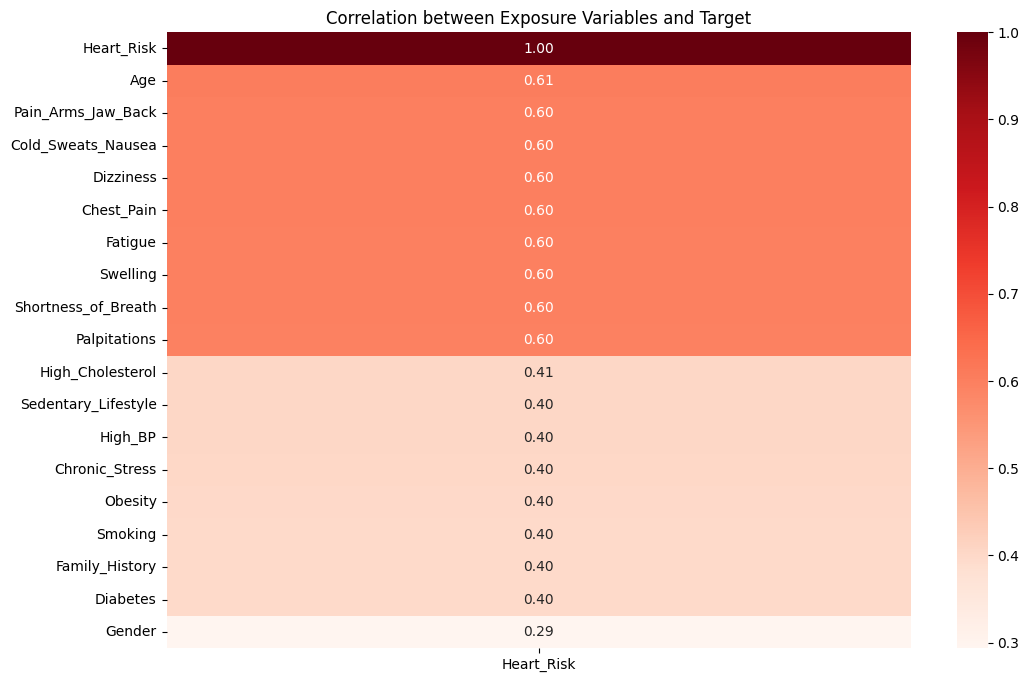

In [ ]:
#Correlation Heetmap between Exposures and Target
plt.figure(figsize=(12, 8))
target_corr = df.corr()[['Heart_Risk']].sort_values(by='Heart_Risk', ascending=False)
sns.heatmap(target_corr, annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation between Exposure Variables and Target')
plt.show()

##Binary Logistic Regression Model
### VIF : Variance Inflation Factor

In [ ]:
#VIF Calculation
X_vif = df.drop(['Heart_Risk'], axis=1) #Obtainin Only Exposure Variables to calculate VIF
X_vif = sm.add_constant(X_vif) #Getting A reference Category for each variable

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("\n--- VIF Results ---")
print(vif_data.sort_values(by="VIF", ascending=False))

#According to VIF values : Since all vif values are lower that 5 the model cab be appliesd


--- VIF Results ---
                Feature        VIF
0                 const  13.149802
18                  Age   1.459369
7    Pain_Arms_Jaw_Back   1.453428
8    Cold_Sweats_Nausea   1.449788
5             Dizziness   1.449760
6              Swelling   1.447197
1            Chest_Pain   1.445860
3               Fatigue   1.445207
2   Shortness_of_Breath   1.444974
4          Palpitations   1.441078
10     High_Cholesterol   1.165538
9               High_BP   1.165408
16       Chronic_Stress   1.164450
14  Sedentary_Lifestyle   1.163789
13              Obesity   1.160350
12              Smoking   1.158037
15       Family_History   1.157871
11             Diabetes   1.155911
17               Gender   1.080938


## Model Estimation

In [ ]:
#Target is Binary - There is an excepted multicolinearity between exposure
#Binary Logistic Model Can be Applied

#1.Determine X's & Y
X=sm.add_constant(df.drop(['Heart_Risk'],axis=1))
Y=df['Heart_Risk']

#2.Applying Trainting & Testing Data to gaurantee model True Prdedicting Power
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

#3.Apply Model code
Model = sm.Logit(y_train,X_train).fit()

# The model managed to reach

Optimization terminated successfully.
         Current function value: 0.022631
         Iterations 12


In [ ]:
#4.Check Mpodel Accuracy of predicting with CONFUSION MATRIX
y_prob_test = Model.predict(X_test)
y_pred_test = (y_prob_test > 0.5).astype(int)

print(classification_report(y_test, y_pred_test))
#The Marix Proved That the model has a PERFECT Prediction for the data


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6998
           1       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



AUC Score: 0.9996


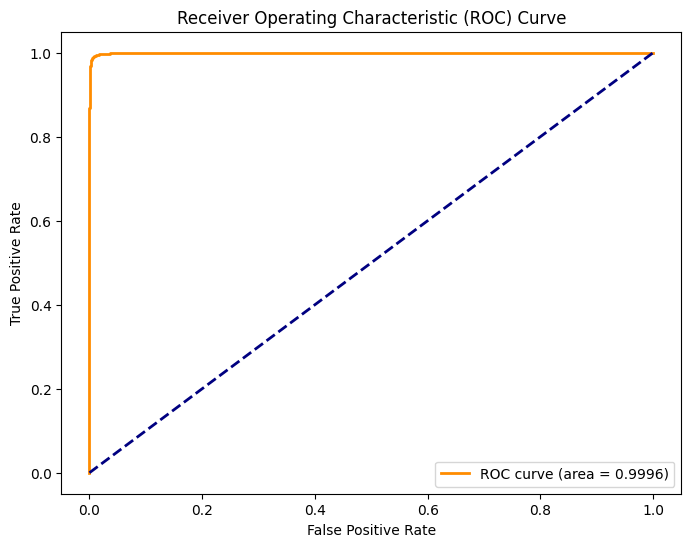

In [ ]:
# 1. حساب الـ ROC Curve
# y_test هي القيم الحقيقية، و y_prob_test هي الاحتمالات المستخرجة من الموديل
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

# 2. حساب قيمة الـ AUC
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f}")

# 3. رسم المنحنى (ROC Curve)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # خط الصدفة
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#Print Model Summary and goodness of fit
print(Model.summary())

                           Logit Regression Results                           
Dep. Variable:             Heart_Risk   No. Observations:                56000
Model:                          Logit   Df Residuals:                    55981
Method:                           MLE   Df Model:                           18
Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.9674
Time:                        19:10:36   Log-Likelihood:                -1267.3
converged:                       True   LL-Null:                       -38816.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -26.1111      0.616    -42.408      0.000     -27.318     -24.904
Chest_Pain              2.7550      0.116     23.743      0.000       2.528       2.982
Shortness_of_Bre

##Obtaining Odds Ratios

In [ ]:
#Obtaining Model Coeffitients
Model_Results = Model.params.to_frame(name='Coeffitients')

In [ ]:
#Get P-values , Odds Ratios and Confideence intervals
Model_Results['Odds_Ratio'] = np.exp(Model_Results['Coeffitients'])
Model_Results['P-Value'] = Model.pvalues
conf=Model.conf_int()
Model_Results['LOWER_CI'] = np.exp(conf[0])
Model_Results['UPPER_CI'] = np.exp(conf[0])

Model_Results.to_excel('Impact.xlsx',index_label='Variable')


##Risk_Prpbabilites


In [ ]:
##Obtain Risk Probability for all dataset  $$Probability = 1/{1 + e^{-(Intercept + \sum \beta X)}}
df['Risk_Probability']= Model.predict(X)
df['Risk_Probability'].describe() #The values are written in a scientific notation - They need to be rounded by 3 disemal places

,Risk_Probability
count,7.000000e+04
mean,5.000172e-01
std,4.936901e-01
min,6.411786e-11
25%,1.260155e-05
50%,5.015117e-01
75%,9.999842e-01
max,1.000000e+00


In [ ]:
df['Risk_Probability']=df['Risk_Probability'].round(2)

In [ ]:
df['Risk_Probability'].describe()

,Risk_Probability
count,70000.000000
mean,0.500012
std,0.493884
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


#Heart Disease Risk Profile
##1. Classify Patients based risk Probability  to High , Moderate & Low
##2. Define Age Distribution and The common exposures in each group



In [ ]:
# First : Define the Classifiyng approach of  Risk Probability :
def Classify_Risk(prob):
  if prob < 0.3: return 'Low Risk'
  elif prob < 0.7: return 'Medium Risk'
  else: return 'High Risk'


In [ ]:
# Second : Apply the Classiying Func. to risk probability
df['Risk_Probability'] = df['Risk_Probability'].apply(Classify_Risk)

In [ ]:
#Final : Obtain Risk Profile :
#Deside_Features to check
features_to_check = ['Chest_Pain','Fatigue','High_BP', 'High_Cholesterol', 'Smoking', 'Diabetes', 'Obesity', 'Chronic_Stress']

#Print the Final Table :
final_profile = df.groupby('Risk_Probability').agg({
    'Age': ['min', 'max', 'mean'], # Range of Age
    **{feat: 'mean' for feat in features_to_check} # نسبة انتشار الأعراض
}).round(2)

print(final_profile)

                 Age            Chest_Pain Fatigue High_BP High_Cholesterol  \
                 min max   mean       mean    mean    mean             mean   
Risk_Probability                                                              
High Risk         23  84  64.47       0.80     0.8    0.70             0.70   
Low Risk          20  82  44.40       0.20     0.2    0.29             0.29   
Medium Risk       20  84  56.61       0.48     0.5    0.51             0.50   

                 Smoking Diabetes Obesity Chronic_Stress  
                    mean     mean    mean           mean  
Risk_Probability                                          
High Risk           0.70     0.70    0.70           0.70  
Low Risk            0.30     0.30    0.30           0.30  
Medium Risk         0.49     0.51    0.52           0.44  


In [ ]:
# 1. Determine Features to check
top_8_features = ['Chest_Pain','Fatigue','High_BP', 'High_Cholesterol', 'Smoking', 'Diabetes', 'Obesity', 'Chronic_Stress']

# 2. Calculate sum of factors
df['Total_Factors'] = df[top_8_features].sum(axis=1)

# 3. Distribute the number of factors for each risk category
# سنستخدم crosstab لحساب عدد الأشخاص لكل (فئة مخاطر) مقابل (عدد العوامل)
factor_distribution = pd.crosstab(df['Risk_Probability'], df['Total_Factors'])

# 4. Transform the factors combination number to a percentage
factor_dist_pct = factor_distribution.div(factor_distribution.sum(axis=1), axis=0)*100

# 5. Show the table
print("%Prevelance of factors in each Risk Category")
print(factor_dist_pct.round(2))

#Now Obtain as an excel file
factor_dist_pct.to_excel('Risk_Factors_Density_Report.xlsx')

%Prevelance of factors in each Risk Category
Total_Factors        0      1      2      3      4      5      6      7    8
Risk_Probability                                                            
High Risk         0.00   0.05   0.52   3.02  10.74  23.78  30.76  23.82  7.3
Low Risk          7.53  23.37  31.62  23.25  10.62   3.04   0.50   0.06  0.0
Medium Risk       0.00   3.08   8.38  23.08  32.65  23.42   7.69   1.71  0.0


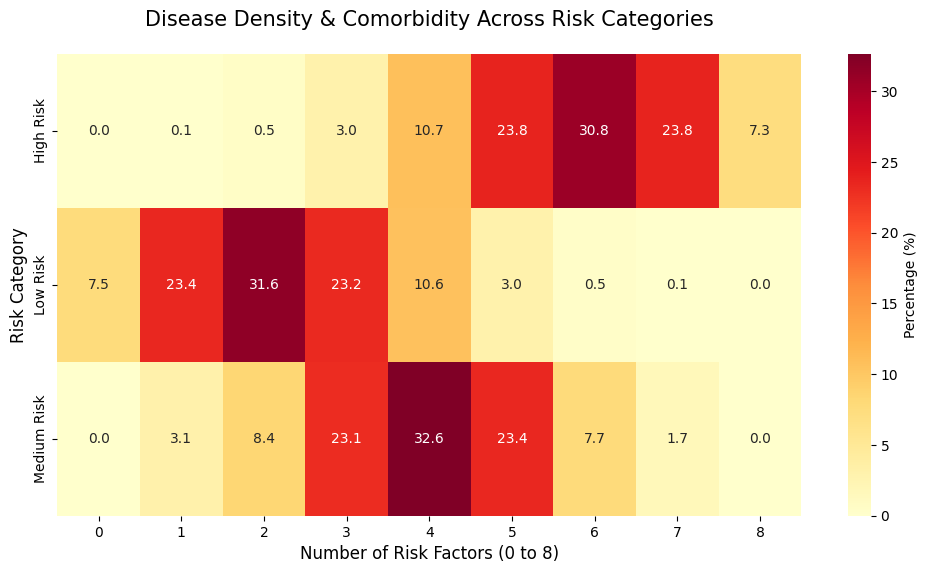

In [ ]:
# Figure Size
plt.figure(figsize=(12, 6))

# Factors Distribution by Heat map (factor_dist_pct)
sns.heatmap(factor_dist_pct, annot=True, cmap="YlOrRd", fmt=".1f", cbar_kws={'label': 'Percentage (%)'})

#Titles :
plt.title('Disease Density & Comorbidity Across Risk Categories', fontsize=15, pad=20)
plt.xlabel('Number of Risk Factors (0 to 8)', fontsize=12)
plt.ylabel('Risk Category', fontsize=12)

plt.show()